# Marketing Attribution & ROI Dashboard

## Business Metrics Analysis

Objectives:
- Calculate Marketing KPIs
- Analyze Channel Performance
- Analyze Campaign Performance
- Evaluate Revenue & Conversion Metrics
- Prepare data for Attribution Modeling

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

In [27]:
ad_df = pd.read_csv("ad_spend_data.csv")
web_df = pd.read_csv("web_analytics_log.csv")
crm_df = pd.read_csv("crm_conversion_data.csv")

In [28]:
ad_df.head()
web_df.head()
crm_df.head()

,customer_id,conversion_date,revenue_usd,last_touch_channel,last_touch_campaign,product_purchased,country
0,USR_01556,2024-03-17,106.69,TikTok,TikTok_Video1,Basic Plan,USA
1,USR_01940,2024-02-04,202.25,Google_Search,GSearch_Brand,Basic Plan,UK
2,USR_00475,2024-03-25,406.54,Google_Search,GSearch_Brand,Pro Plan,UK
3,USR_01552,2024-01-15,122.89,Email,Email_Promo,Enterprise Plan,Canada
4,USR_01314,2024-02-07,22.03,TikTok,TikTok_Promo,Enterprise Plan,Germany


In [29]:
total_spend = ad_df["amount_spent_usd"].sum()

print(f"Total Spend: ${total_spend:,.2f}")

Total Spend: $1,236,166.50


In [30]:
total_revenue = crm_df["revenue_usd"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $157,479.27


In [31]:
total_clicks = ad_df["clicks"].sum()

print("Total Clicks:", total_clicks)

Total Clicks: 948432


In [32]:
total_impressions = ad_df["impressions"].sum()

print("Total Impressions:", total_impressions)

Total Impressions: 28405568


In [33]:
total_conversions = len(crm_df)

print("Total Conversions:", total_conversions)

Total Conversions: 600


In [34]:
ctr = (total_clicks / total_impressions) * 100

print(f"CTR: {ctr:.2f}%")

CTR: 3.34%


In [35]:
cpc = total_spend / total_clicks

print(f"CPC: ${cpc:.2f}")

CPC: $1.30


In [36]:
cac = total_spend / total_conversions

print(f"CAC: ${cac:.2f}")

CAC: $2060.28


In [37]:
roas = total_revenue / total_spend

print(f"ROAS: {roas:.2f}")

ROAS: 0.13


In [38]:
kpi_summary = pd.DataFrame({
    "Metric":[
        "Total Spend",
        "Total Revenue",
        "Total Clicks",
        "Total Impressions",
        "Total Conversions",
        "CTR %",
        "CPC",
        "CAC",
        "ROAS"
    ],
    "Value":[
        total_spend,
        total_revenue,
        total_clicks,
        total_impressions,
        total_conversions,
        ctr,
        cpc,
        cac,
        roas
    ]
})

kpi_summary["Value"] = kpi_summary["Value"].apply(
    lambda x: f"{x:,.2f}"
)

kpi_summary

,Metric,Value
0,Total Spend,"1,236,166.50"
1,Total Revenue,"157,479.27"
2,Total Clicks,"948,432.00"
3,Total Impressions,"28,405,568.00"
4,Total Conversions,600.00
5,CTR %,3.34
6,CPC,1.30
7,CAC,"2,060.28"
8,ROAS,0.13


In [39]:
channel_spend = (
    ad_df.groupby("channel")
    ["amount_spent_usd"]
    .sum()
    .sort_values(ascending=False)
)

channel_spend

channel
Google_Search    483302.68
Meta_Facebook    304221.15
LinkedIn         252163.24
TikTok           150570.08
Email             45909.35
Organic               0.00
Name: amount_spent_usd, dtype: float64

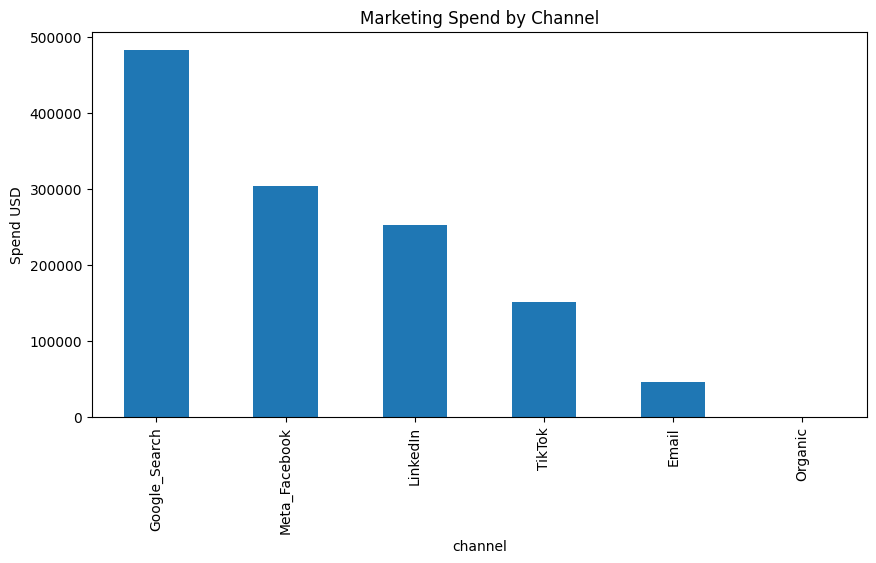

In [40]:
channel_spend.plot(kind="bar")

plt.title("Marketing Spend by Channel")
plt.ylabel("Spend USD")

plt.show()

In [41]:
channel_revenue = (
    crm_df.groupby("last_touch_channel")
    ["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)

channel_revenue

last_touch_channel
Google_Search    43583.44
Meta_Facebook    41564.63
TikTok           24587.92
LinkedIn         16716.83
Organic          16696.59
Email            14329.86
Name: revenue_usd, dtype: float64

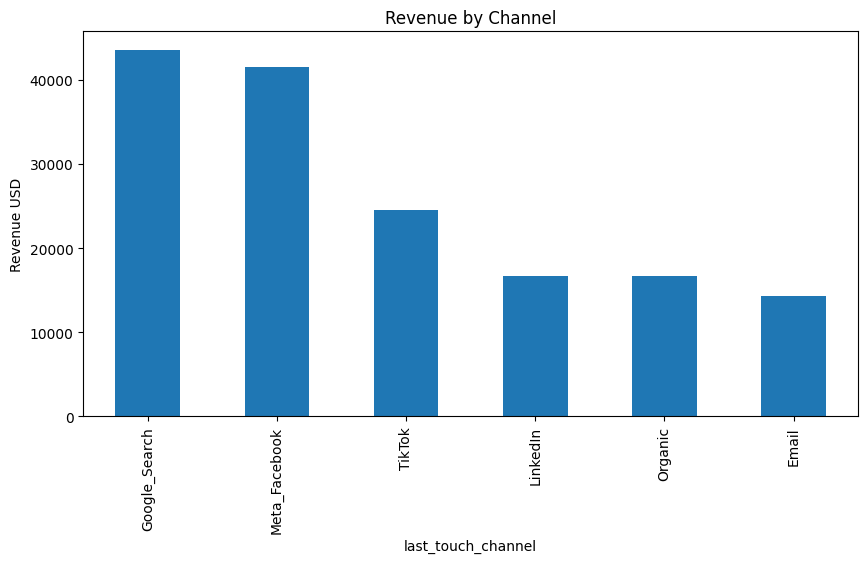

In [42]:
channel_revenue.plot(kind="bar")

plt.title("Revenue by Channel")
plt.ylabel("Revenue USD")

plt.show()

In [43]:
campaign_spend = (
    ad_df.groupby("campaign")
    ["amount_spent_usd"]
    .sum()
    .sort_values(ascending=False)
)

campaign_spend.head(10)

campaign
GSearch_Generic       167827.60
GSearch_Brand         158421.98
GSearch_Competitor    157053.10
LinkedIn_Lead         130127.99
LinkedIn_B2B          122035.25
FB_Retargeting        104496.64
FB_Awareness          100486.74
FB_Lookalike           99237.77
TikTok_Promo           77511.58
TikTok_Video1          73058.50
Name: amount_spent_usd, dtype: float64

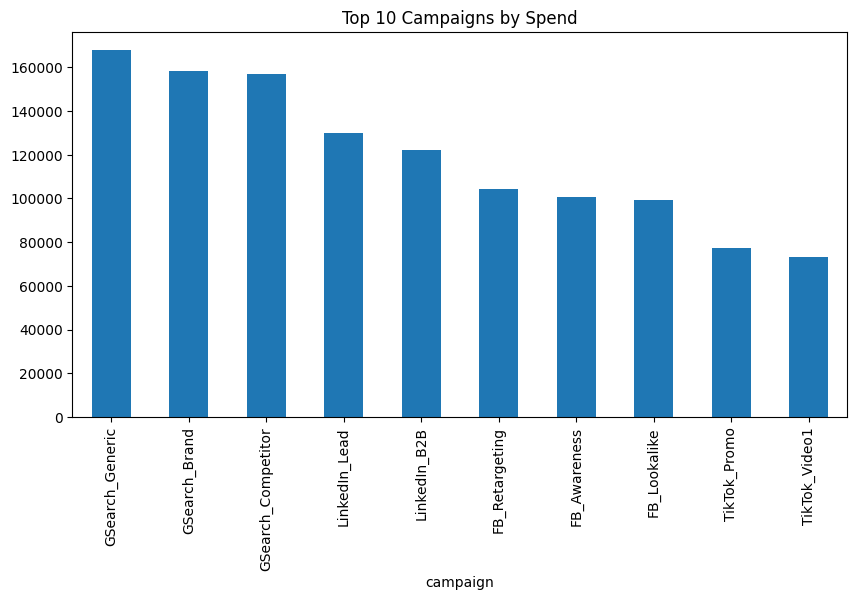

In [44]:
campaign_spend.head(10).plot(kind="bar")

plt.title("Top 10 Campaigns by Spend")

plt.show()

In [45]:
web_df["device"].value_counts()

device
tablet     2085
mobile     1983
desktop    1966
Name: count, dtype: int64

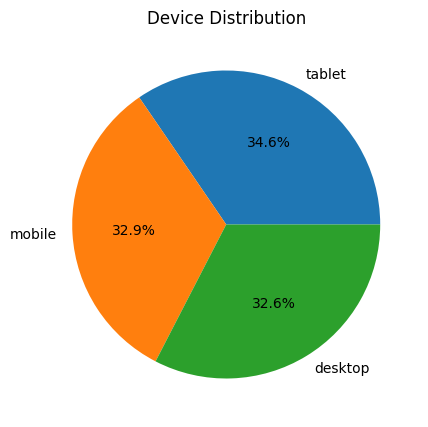

In [46]:
web_df["device"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Device Distribution")

plt.ylabel("")

plt.show()

In [47]:
crm_df["country"].value_counts()

country
Canada       109
UK           106
Germany       99
India         99
Australia     97
USA           90
Name: count, dtype: int64

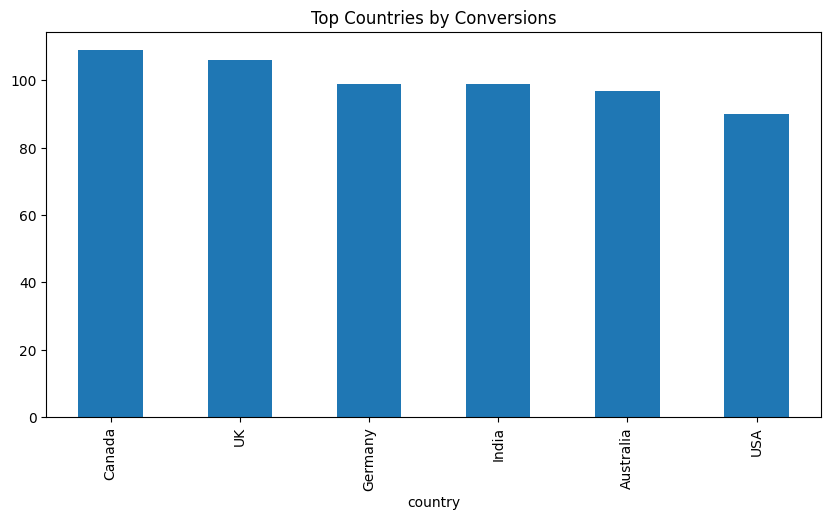

In [48]:
crm_df["country"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Countries by Conversions")

plt.show()

In [49]:
sessions = web_df["session_id"].nunique()

users = web_df["user_id"].nunique()

conversions = len(crm_df)

funnel_df = pd.DataFrame({
    "Stage":[
        "Sessions",
        "Users",
        "Conversions"
    ],
    "Count":[
        sessions,
        users,
        conversions
    ]
})

funnel_df

,Stage,Count
0,Sessions,6016
1,Users,2000
2,Conversions,600


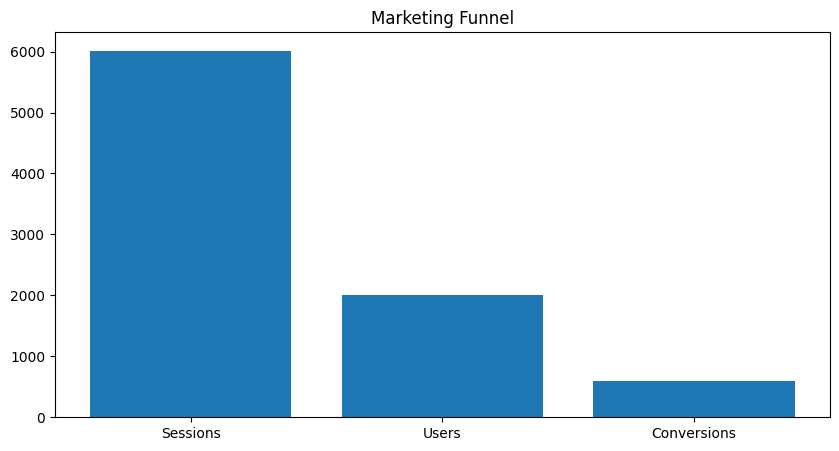

In [50]:
plt.bar(
    funnel_df["Stage"],
    funnel_df["Count"]
)

plt.title("Marketing Funnel")

plt.show()

## Business Insights

Key Findings

1. Total marketing spend was $1.24 million.
2. Total revenue generated was $157.5 thousand.
3. Campaigns achieved 28.4 million impressions and 948 thousand clicks.
4. Overall CTR was 3.34%, indicating reasonable audience engagement.
5. Average CPC was $1.30 per click.
6. Total conversions recorded were 600 customers.
7. CAC was approximately $2,060 per customer, which is very high.
8. ROAS was only 0.127, meaning every $1 spent generated only $0.13 in revenue.
9. Based on these metrics, current campaign performance is not profitable.
10. Attribution analysis is required to identify the channels and campaigns contributing most effectively to conversions.

## Business Insights

- Total marketing investment has been summarized.
- Revenue generated from campaigns has been calculated.
- ROAS provides an overall measure of campaign profitability.